In [1]:
import os 
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

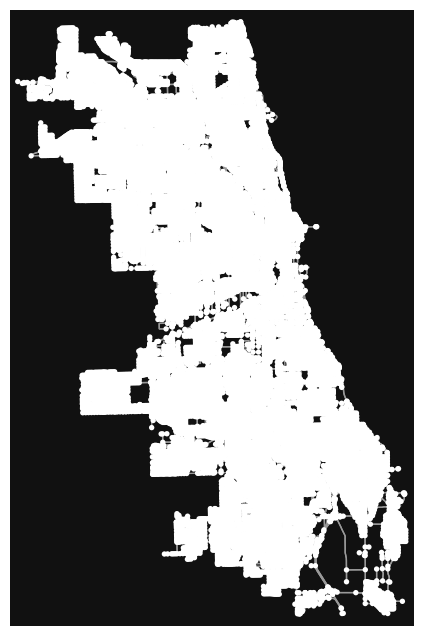

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [45]:
import osmnx as ox

## IMPORT CITY
city = ox.graph_from_place('Chicago, IL, USA', network_type='drive')

ox.plot_graph(city)

In [46]:
import networkx as nx
import numpy as np

## ADDING EDGE PROPERTIES
city = ox.speed.add_edge_speeds(city)
city = ox.speed.add_edge_travel_times(city)

## GENERATING IMPORTANT INFO
indexes = {node: i for i, node in enumerate(city.nodes)}
travel_times_dict = nx.get_edge_attributes(city, 'travel_time')

## STARTING AND ENDING NODES
str_address = '1008 s 4th st, champaign, il'
end_address = '2610 N Prospect Ave, Champaign, IL'

#from utils import node_from_address, get_unique_path

#starting_node = node_from_address(city, str_address)
#final_node = node_from_address(city, end_address)

In [47]:
attrs = nx.get_edge_attributes(city, 'highway')

all_ = []

for (a, value) in attrs.items():
    if value not in all_:
        print(value)
        all_.append(value)

motorway_link
motorway
tertiary
trunk
secondary
residential
unclassified
primary
secondary_link
busway
['secondary', 'tertiary']
['motorway_link', 'primary']
tertiary_link
living_street
['secondary', 'motorway_link']
trunk_link
['residential', 'unclassified']
['tertiary', 'residential']
['secondary', 'residential']
primary_link
['motorway', 'trunk']
closed
['living_street', 'residential']
['tertiary', 'motorway_link']
['secondary', 'secondary_link']
emergency_bay


(<Figure size 800x800 with 1 Axes>, <Axes: >)

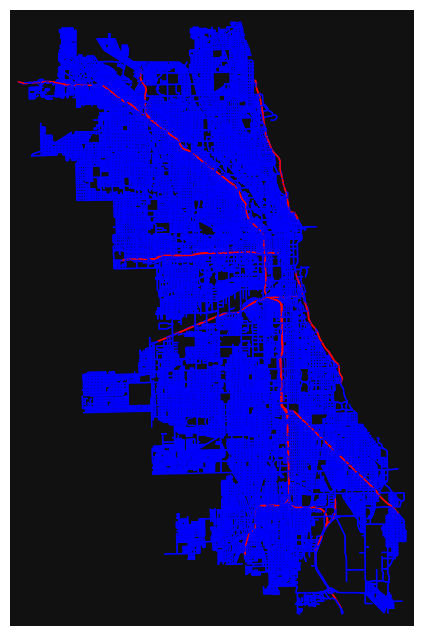

In [49]:
edge_attributes = ox.graph_to_gdfs(city, nodes=False).columns
attrs = nx.get_edge_attributes(city, 'highway')
t = [a for a, value in attrs.items() if value == 'motorway']

edge_color = ['r' if edge in t else 'b' for edge in city.edges]
ox.plot_graph(city, edge_color=edge_color, node_size=0, show=False, close=False)

In [15]:
## FILTERING OUT UNDESIRABLE NODES, GENERATING INCIDENCE MATRIX

'''banned_coords = [(40.130902, -88.243662), 
                (40.130462, -88.238855), 
                (40.132660, -88.243546),
                (40.132989, -88.257875),
                (40.127197, -88.245215)]

banned_nodes = [ox.nearest_nodes(city, lon, lat) for lat, lon in banned_coords]'''

banned_nodes = []
banned_edges = []
banned_edges_idx = []

edges = list(city.edges)

n_points = len(city.nodes)
n_edges = len(city.edges)

A = np.zeros((n_points, n_edges))

for i, (u, v, k) in enumerate(edges):
    if u in banned_nodes or v in banned_nodes:
        banned_edges += [(u, v, k)]
        banned_edges_idx += [i]
        pass

    A[indexes[u]][i] = -1
    A[indexes[v]][i] = 1

In [16]:
## LINEAR PROGRAM LOGIC
import gurobipy as gp
from gurobipy import GRB

b = np.zeros(n_points)

b[indexes[starting_node]] = -1
b[indexes[final_node]] = 1

f = np.zeros(n_edges)

m = gp.Model("lp")

m.Params.LogToConsole = 0
m.Params.Method = 0

f = m.addMVar(shape=n_edges, vtype=GRB.CONTINUOUS, lb=0, name="")

weights = [travel_time for edge, travel_time in travel_times_dict.items()]

m.addConstr(A@f==b)
obj = np.array(weights)@f
m.setObjective(obj, GRB.MINIMIZE)

Set parameter Username
Academic license - for non-commercial use only - expires 2024-10-13


Path length: 37m16s, 2236.5s


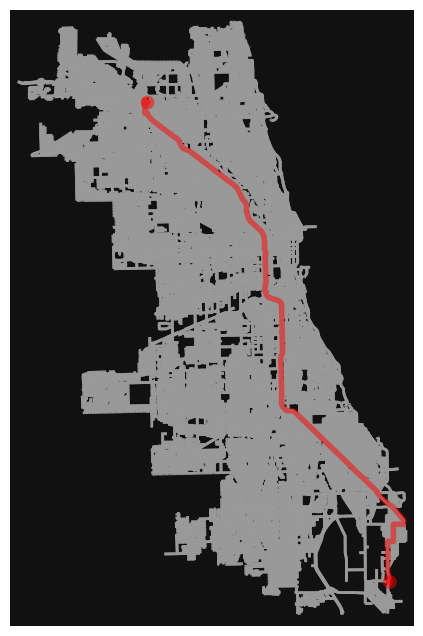

In [18]:
## TESTING FOR DIFFERENT BUDGETS
'''max_budget = 10000
for budget in range(1):'''
m.addConstr(gp.quicksum(f[i] for i in banned_edges_idx) <= 10)#((max_budget-1)-budget)*2)

m.optimize()

flows = m.getAttr("X", m.getVars())

objval = m.ObjVal

print(f'Path length: {int(objval//60)}m{round(objval%60)}s, {objval}s')

flowed_edges_idx = []
flowed_edges = []

for i in range(len(flows)):
    if flows[i]:
        #print(flows[i])
        flowed_edges_idx += [i]

flowed_pts = []

for i, (u, v, k) in enumerate(city.edges):
    if i in flowed_edges_idx:
        flowed_edges += [(u, v, k)]
        #if i in banned_edges_idx:
            #print(i, edges[i])

        for pt in (u, v):
            if pt not in flowed_pts:
                flowed_pts += [pt]

from utils import get_edges_and_points

path, pts = get_edges_and_points(flowed_edges, starting_node=starting_node, final_node=final_node)

fig, ax = ox.plot_graph_route(city, pts, node_color='w', node_edgecolor='k', node_size=0, 
                        node_zorder=3, edge_linewidth=2)



In [7]:
for current_edge in flowed_edges:
    matching_edges = [edge for edge in flowed_edges if edge[0] == current_edge[1]]
    if len(matching_edges) == 2: print(current_edge)

In [141]:
'''def get_edges_for_real(edges: list, starting_node: int, final_node: int) -> list:
    flowed_edges = edges.copy()

    current_point = starting_node
    matching_edges = [edge for edge in flowed_edges if edge[0] == current_point]

    if len(matching_edges) == 1 and matching_edges[0][1] == final_node:
        return matching_edges

    for edge in matching_edges:
        all_edges = get_edges_for_real([edg for edg in edges if edg != edge], edge[1], final_node)
        
        return all_edges + [edge]'''

[(0, 1),
 (1, 2),
 (2, 3),
 (3, 4),
 (4, 5),
 (5, 6),
 (6, 7),
 (7, 8),
 (8, 9),
 (9, 10),
 (10, 11),
 (11, 12),
 (12, 13),
 (13, 14),
 (14, 15),
 (15, 16),
 (16, 17),
 (17, 18),
 (18, 19),
 (19, 20)]

In [146]:
len(get_edges_for_real(flowed_edges, starting_node, final_node))

67

In [140]:
len(flowed_edges)

67

In [7]:
def get_edges_for_real_local(edges: list, starting_node: int, final_node: int) -> list:
    matching_edges = [edge for edge in edges if edge[0] == starting_node]

    if len(matching_edges) == 1 and matching_edges[0][1] == final_node:
        return matching_edges

    for matching_edge in matching_edges:
        all_edges = get_edges_for_real_local([edge for edge in edges if edge != matching_edge], matching_edge[1], final_node)
        
        return all_edges + [matching_edge]

In [8]:
get_edges_for_real_local(flowed_edges, starting_node, final_node)

[(5440546962, 2375296144, 0),
 (5440546961, 5440546962, 0),
 (1518917867, 5440546961, 0),
 (194668461, 1518917867, 0),
 (38133216, 194668461, 0),
 (37963930, 38133216, 0),
 (38146585, 37963930, 0),
 (3273524767, 38146585, 0),
 (6119772432, 3273524767, 0),
 (1929711603, 6119772432, 0),
 (1929711495, 1929711603, 0),
 (6119772436, 1929711495, 0),
 (5680618729, 6119772436, 0),
 (5680617585, 5680618729, 0),
 (10101649870, 5680617585, 0),
 (10101649866, 10101649870, 0),
 (10101638415, 10101649866, 0),
 (38009741, 10101638415, 0),
 (37986833, 38009741, 0),
 (38009732, 37986833, 0),
 (38009731, 38009732, 0),
 (37970446, 38009731, 0),
 (38009727, 37970446, 0),
 (37999274, 38009727, 0),
 (38128444, 37999274, 0),
 (37982955, 38128444, 0),
 (38047403, 37982955, 0),
 (38068242, 38047403, 0),
 (38007920, 38068242, 0),
 (37989318, 38007920, 0),
 (38003956, 37989318, 0),
 (37997462, 38003956, 0),
 (38083033, 37997462, 0),
 (38135457, 38083033, 0),
 (38135864, 38135457, 0),
 (38035942, 38135864, 0),
 (